In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Read data
df = pd.read_excel('Wine.xlsx')
X = np.array(df.iloc[:, :-1]) # 排 除 最 後 一 欄 標 籤
y = np.array(df.iloc[:, -1]) # 標籤欄
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30)
# Standardize data
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.fit_transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_original = LogisticRegression(solver = solver, **opts)
clf_original.fit(X_train_, y_train)
y_pred = clf_original.predict(X_test_)
# 測 試 資 料 之 準 確 率 回 報
print(f'{accuracy_score(y_test, y_pred):.2%}\n')
print(f'{clf_original.score(X_test_, y_test):.2%}\n')
print(classification_report(y_test, y_pred))


96.30%

96.30%

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
           2       1.00      0.92      0.96        25
           3       0.82      1.00      0.90         9

    accuracy                           0.96        54
   macro avg       0.94      0.97      0.95        54
weighted avg       0.97      0.96      0.96        54



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [7]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
Cs = np.logspace(-5, 5, 20)
clf_original = LogisticRegressionCV(solver = solver, \
                Cs=Cs, **opts)
clf_original.fit(X_train_, y_train)
y_pred = clf_original.predict(X_test_)
# 測 試 資 料 之 準 確 率 回 報
print(f'{accuracy_score(y_test, y_pred):.2%}\n')
print(f'{clf_original.score(X_test_, y_test):.2%}\n')
print(classification_report(y_test, y_pred))


87.04%

87.04%

              precision    recall  f1-score   support

           1       0.90      0.90      0.90        20
           2       0.91      0.80      0.85        25
           3       0.75      1.00      0.86         9

    accuracy                           0.87        54
   macro avg       0.85      0.90      0.87        54
weighted avg       0.88      0.87      0.87        54



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_PCA = LogisticRegression(solver = solver, **opts)
clf_PCA.fit(Z_train, y_train)
y_pred = clf_PCA.predict(Z_test)
print(f'{clf_PCA.score(Z_test, y_test):.2%}\n')
print(classification_report(y_test, y_pred))

94.44%

              precision    recall  f1-score   support

           1       0.90      0.95      0.93        20
           2       0.96      0.92      0.94        25
           3       1.00      1.00      1.00         9

    accuracy                           0.94        54
   macro avg       0.95      0.96      0.96        54
weighted avg       0.95      0.94      0.94        54



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


換檔案

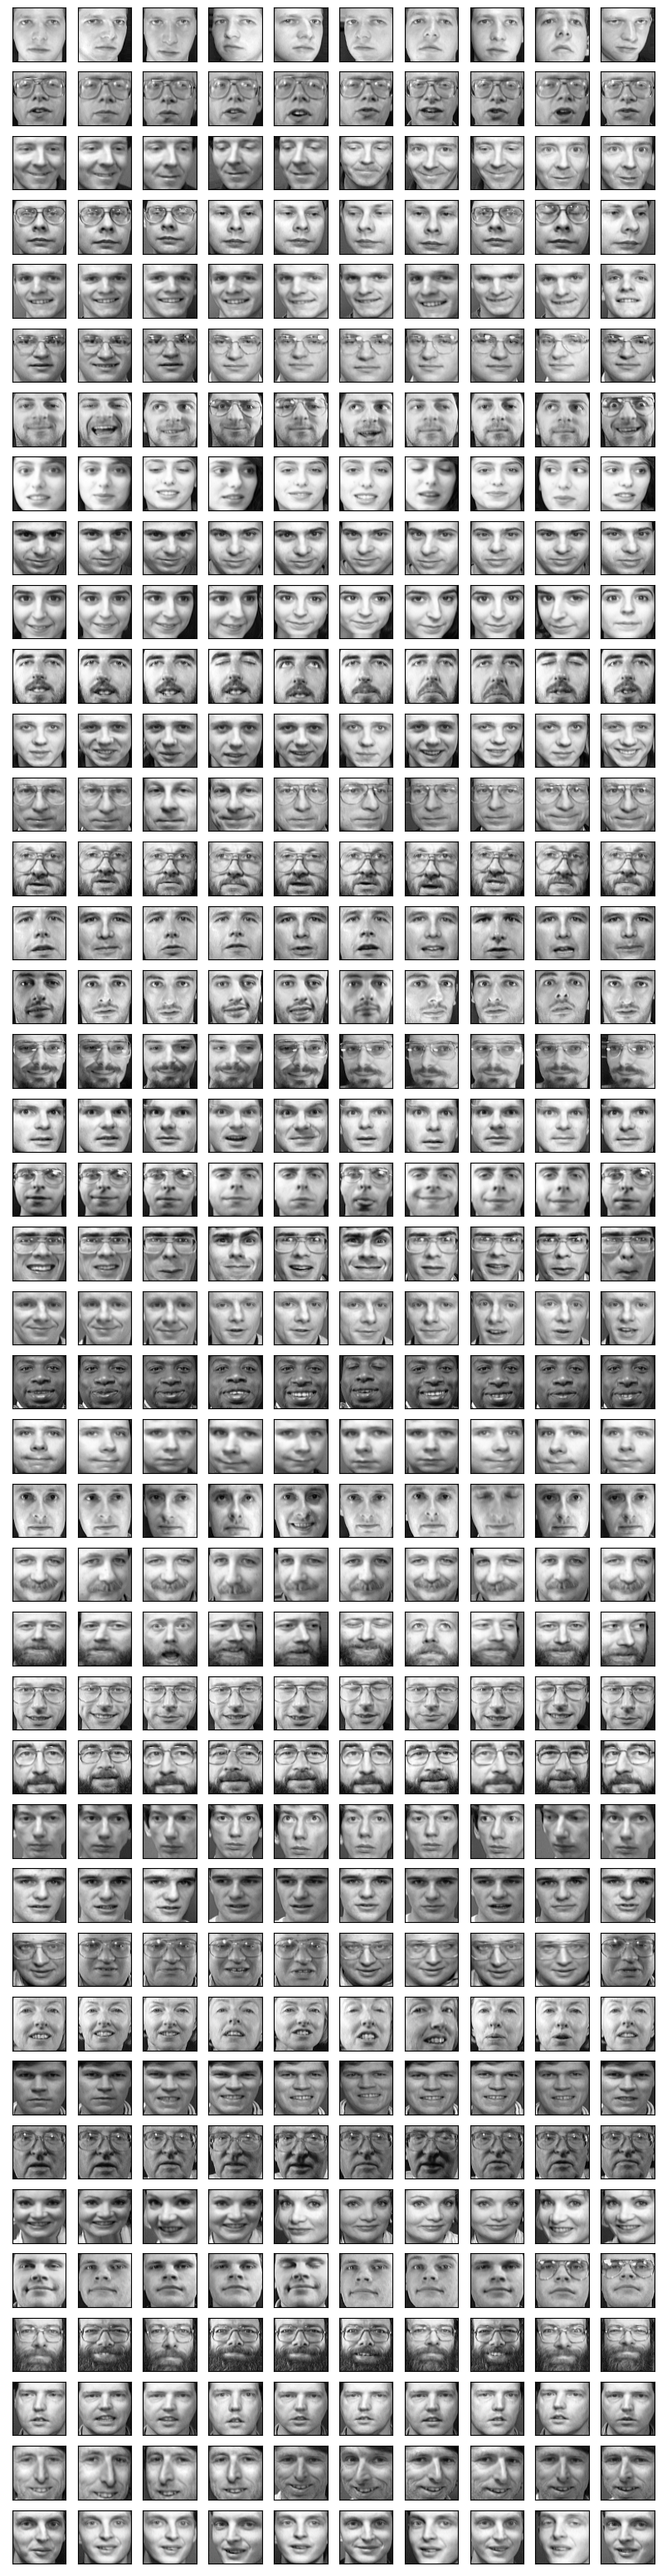

In [20]:
import matplotlib.pyplot as plt
def show_montage(X, n, m, h, w):
    # X: 影 像 資 料 矩 陣 ， 每 行 代 表 一 張 影 像
    # n, m: 每 張 影 像 的 大 小 n x m
    # h, w : 建 立 一 個 蒙 太 奇 圖 陣 ， 大小 figsize = (w,h)
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h: # 影 像 張 數 不 到 w x h 張 ， 用 0 向量補齊
        X = np.c_[X, np.zeros((X.shape[0], w*h-X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:,i].reshape(m, n), cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()
#
df = pd.read_csv('face_data.csv')
n_persons = df['target'].nunique 
X = np.array(df.iloc[:, :-1]) # 排 除 最 後 一 欄 標 籤
y = np.array(df.iloc[:, -1]) # 標籤欄
n,m = 64,64
show_montage(X.T,n,m,40,10)
#40個人，每人10張

In [21]:
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30)
# Standardize data
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.fit_transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_original = LogisticRegression(solver = solver, **opts)
clf_original.fit(X_train_, y_train)
y_pred = clf_original.predict(X_test_)
# 測 試 資 料 之 準 確 率 回 報
print(f'{accuracy_score(y_test, y_pred):.2%}\n')
print(f'{clf_original.score(X_test_, y_test):.2%}\n')
print(classification_report(y_test, y_pred))


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


94.17%

94.17%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4
           2       0.50      1.00      0.67         1
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         4
           7       0.80      0.80      0.80         5
           8       1.00      1.00      1.00         2
           9       0.50      0.33      0.40         3
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      0.67      0.80         3
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00         3
          1

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.4s finished


In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 100).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_PCA = LogisticRegression(solver = solver, **opts)
clf_PCA.fit(Z_train, y_train)
y_pred = clf_PCA.predict(Z_test)
print(f'{clf_PCA.score(Z_test, y_test):.2%}\n')
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


93.33%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4
           2       0.50      1.00      0.67         1
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         4
           7       0.75      0.60      0.67         5
           8       1.00      1.00      1.00         2
           9       0.50      0.33      0.40         3
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      0.67      0.80         3
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00         3
          17       

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


換資料

In [24]:
import numpy as np
import scipy.io
D = scipy.io.loadmat('allFaces.mat')
X = D['faces'].T # 32256 x 2410, each column represents an image
# y = np.ndarray.flatten(D['nfaces'])
m = D['m'].item() # 168
n = D['n'].item() # 192
n_persons = int(D['person']) # 38
y2 = np.ndarray.flatten(D['nfaces'])
y = np.repeat(np.arange(len(y2)),y2)
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30)
# Standardize data
scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.fit_transform(X_test)

C:\Users\jameslin\AppData\Local\Temp\ipykernel_7464\124484872.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_persons = int(D['person']) # 38


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_original = LogisticRegression(solver = solver, **opts)
clf_original.fit(X_train_, y_train)
y_pred = clf_original.predict(X_test_)
# 測 試 資 料 之 準 確 率 回 報
print(f'{accuracy_score(y_test, y_pred):.2%}\n')
print(f'{clf_original.score(X_test_, y_test):.2%}\n')
print(classification_report(y_test, y_pred))


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


96.54%

96.54%

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       1.00      1.00      1.00        20
           2       0.82      1.00      0.90        18
           3       0.94      1.00      0.97        16
           4       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        20
           6       1.00      0.89      0.94        19
           7       0.96      1.00      0.98        23
           8       0.91      1.00      0.95        20
           9       1.00      0.95      0.97        20
          10       0.92      1.00      0.96        11
          11       1.00      0.93      0.97        15
          12       1.00      0.95      0.97        20
          13       1.00      1.00      1.00        19
          14       0.95      1.00      0.98        21
          15       1.00      0.94      0.97        17
          16       1.00      0.95      0.98        21
          1

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed: 10.3min finished


In [26]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 250).fit(X_train_)
Z_train = pca.transform(X_train_)
Z_test = pca.transform(X_test_)
opts = dict(tol = 1e-6, max_iter = int(1e6), verbose=1)
solver = 'lbfgs' # ’lbfgs’ is the default
# solver = ’liblinear’
# solver = ’newton−cg’
clf_PCA = LogisticRegression(solver = solver, **opts)
clf_PCA.fit(Z_train, y_train)
y_pred = clf_PCA.predict(Z_test)
print(f'{clf_PCA.score(Z_test, y_test):.2%}\n')
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


95.57%

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       1.00      1.00      1.00        20
           2       0.78      1.00      0.88        18
           3       0.89      1.00      0.94        16
           4       0.93      1.00      0.97        14
           5       1.00      1.00      1.00        20
           6       1.00      0.89      0.94        19
           7       0.96      1.00      0.98        23
           8       0.95      1.00      0.98        20
           9       1.00      0.95      0.97        20
          10       0.92      1.00      0.96        11
          11       1.00      0.93      0.97        15
          12       1.00      0.90      0.95        20
          13       1.00      1.00      1.00        19
          14       0.91      0.95      0.93        21
          15       1.00      0.94      0.97        17
          16       0.95      0.90      0.93        21
          17       

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.0s finished


最佳參數化

In [12]:
from sklearn.model_selection import  GridSearchCV, \
                        StratifiedShuffleSplit

from datetime import datetime

# Get the current date and time

now = datetime.now()

# Format the date and time as a string

now_str = now.strftime("%Y_%m_%d_%H_%M_%S")

results_file = 'data/results_' + now_str + '.csv'



opts = dict(tol = 1e-6, max_iter = int(1e6)) # parameters for LogisticRegression

parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

            'sag','saga'], 'C':[0.1, 1, 10]} # parameters for GridSearchCV

# parameters = {'solver':['lbfgs', 'liblinear', 'newton-cg',\

#                         'sag','saga']}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, \

                            random_state=0) # 5-fold CV

grid = GridSearchCV(estimator=LogisticRegression(**opts), \

                param_grid=parameters, cv=cv, 

                scoring=['accuracy','f1_macro'], refit="accuracy")

grid.fit(X_train, y_train)

# grid.fit(X, y)

cv_logistic = pd.DataFrame(data = grid.cv_results_)

cv_logistic.to_csv(results_file)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

{'C': 1, 'solver': 'liblinear'}
0.9789473684210526
LogisticRegression(C=1, max_iter=1000000, solver='liblinear', tol=1e-06)


SVM

In [13]:
from sklearn.svm import SVC, LinearSVC
C = 1 # SVM regularization parameter
opts = dict(C = C, tol = 1e-6, max_iter = int(1e6))
# opts = dict(C = C, decision_function_shape = ’ovo’, \
# tol = 1e−6, max_iter = int(1e6))
clf_svm = SVC(kernel='linear', **opts)
# clf_svm = SVC(kernel=”rbf”, gamma=0.2, **opts)
# clf_svm = SVC(kernel=”poly”, degree=3, gamma=”auto”, **opts)
# clf_svm = LinearSVC(**opts) # one vs the rest
clf_svm.fit(X_train, y_train)
predictions = clf_svm.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.95      0.95      0.95        21
           2       0.94      0.88      0.91        17
           3       0.94      1.00      0.97        16

    accuracy                           0.94        54
   macro avg       0.94      0.94      0.94        54
weighted avg       0.94      0.94      0.94        54



In [14]:
from sklearn.neural_network import MLPClassifier
# hidden_layers = (512,) # one hidden layer
# activation = ’relu’ # the default
hidden_layers = (30,)
activation = 'logistic'
opts = dict(hidden_layer_sizes = hidden_layers , verbose = True, \
activation = activation, tol = 1e-6, max_iter = int(1e6))
# solver = ’sgd’ # not efficient, need more tuning
# solver = ’lbfgs’ # not suitable here
solver = 'adam' # default solver
clf_MLP = MLPClassifier(solver = solver, **opts)
clf_MLP.fit(X_train, y_train)
predictions = clf_MLP.predict(X_test)
print(classification_report(y_test, predictions))

Iteration 1, loss = 1.21343557
Iteration 2, loss = 1.20275791
Iteration 3, loss = 1.19369026
Iteration 4, loss = 1.18536308
Iteration 5, loss = 1.17756154
Iteration 6, loss = 1.17026761
Iteration 7, loss = 1.16341134
Iteration 8, loss = 1.15692336
Iteration 9, loss = 1.15078270
Iteration 10, loss = 1.14500002
Iteration 11, loss = 1.13958410
Iteration 12, loss = 1.13452020
Iteration 13, loss = 1.12977183
Iteration 14, loss = 1.12528705
Iteration 15, loss = 1.12097377
Iteration 16, loss = 1.11665114
Iteration 17, loss = 1.11195341
Iteration 18, loss = 1.10641170
Iteration 19, loss = 1.09964973
Iteration 20, loss = 1.09176272
Iteration 21, loss = 1.08364699
Iteration 22, loss = 1.07616638
Iteration 23, loss = 1.06962774
Iteration 24, loss = 1.06458273
Iteration 25, loss = 1.06165299
Iteration 26, loss = 1.05973852
Iteration 27, loss = 1.05809171
Iteration 28, loss = 1.05653233
Iteration 29, loss = 1.05503648
Iteration 30, loss = 1.05360385
Iteration 31, loss = 1.05219930
Iteration 32, los